# Análise de Logística e SLA | Case Olist

In [1]:
import pandas as pd

## Carregando os dados

In [2]:
fato_pedidos = pd.read_csv("/content/fato_pedidos.csv")
dim_clientes = pd.read_csv("/content/dim_clientes.csv")
order_reviews = pd.read_csv("/content/olist_order_reviews_dataset.csv")

#Logística e SLA

Nesta etapa, vou analisar o tempo de entrega, o cumprimento dos prazos, os atrasos por estado, a relação entre atraso e satisfação do cliente e o impacto financeiro dos pedidos atrasados.

## 1. Preparação da base para a análise logística

In [3]:
# Pedidos entregues em nível de pedido
pedidos_entregues = fato_pedidos[
    fato_pedidos['order_status'] == 'delivered'
].drop_duplicates(
    subset='order_id'
).copy()

print("Pedidos entregues:", len(pedidos_entregues))

Pedidos entregues: 96478


## 2. Lead Time

O Lead Time representa o tempo decorrido entre a realização do pedido e a entrega ao cliente.

Nesta análise, observo a média, a mediana e a presença de valores extremos para entender o comportamento do prazo de entrega.

In [4]:
# Garantindo o formato das datas
pedidos_entregues['order_purchase_timestamp'] = pd.to_datetime(
    pedidos_entregues['order_purchase_timestamp']
)
pedidos_entregues['order_delivered_customer_date'] = pd.to_datetime(
    pedidos_entregues['order_delivered_customer_date']
)

# Cálculo do Lead Time em dias
pedidos_entregues['lead_time_dias'] = (
    pedidos_entregues['order_delivered_customer_date']
    - pedidos_entregues['order_purchase_timestamp']
).dt.total_seconds() / 86400

print(f"Lead Time médio: {pedidos_entregues['lead_time_dias'].mean():.1f} dias")
print(f"Lead Time mediano: {pedidos_entregues['lead_time_dias'].median():.1f} dias")

# Estatísticas descritivas do Lead Time
pedidos_entregues['lead_time_dias'].describe()

Lead Time médio: 12.6 dias
Lead Time mediano: 10.2 dias


count    96470.000000
mean        12.558217
std          9.546156
min          0.533414
25%          6.766204
50%         10.217477
75%         15.720182
max        209.628611
Name: lead_time_dias, dtype: float64

### 2.1 Identificação de possíveis outliers no Lead Time

Utilizo o método do intervalo interquartil (IQR) para identificar valores extremos do Lead Time.

In [5]:
lead_time = pedidos_entregues['lead_time_dias'].dropna()

Q1_lead = lead_time.quantile(0.25)
Q3_lead = lead_time.quantile(0.75)
IQR_lead = Q3_lead - Q1_lead

limite_superior_lead = Q3_lead + 1.5 * IQR_lead

outliers_lead = lead_time[
    lead_time > limite_superior_lead
]

print("Quantidade de possíveis outliers:", len(outliers_lead))
print(
    "Percentual da base:",
    len(outliers_lead) / len(lead_time) * 100
)

print("Média com outliers:", lead_time.mean())
print(
    "Média sem outliers:",
    lead_time[lead_time <= limite_superior_lead].mean()
)

Quantidade de possíveis outliers: 4896
Percentual da base: 5.075152897273764
Média com outliers: 12.558217098051975
Média sem outliers: 11.048863057093474


**Resultado validado:** foram identificados **4.896 possíveis outliers**, correspondendo a aproximadamente **5,08% da base analisada**. A média do Lead Time passa de aproximadamente **12,55 dias para 11,04 dias** quando esses valores extremos são retirados.

### 2.2 Distribuição do Lead Time

A distribuição permite observar a concentração dos tempos de entrega e verificar a presença de uma cauda formada por entregas extremamente demoradas.

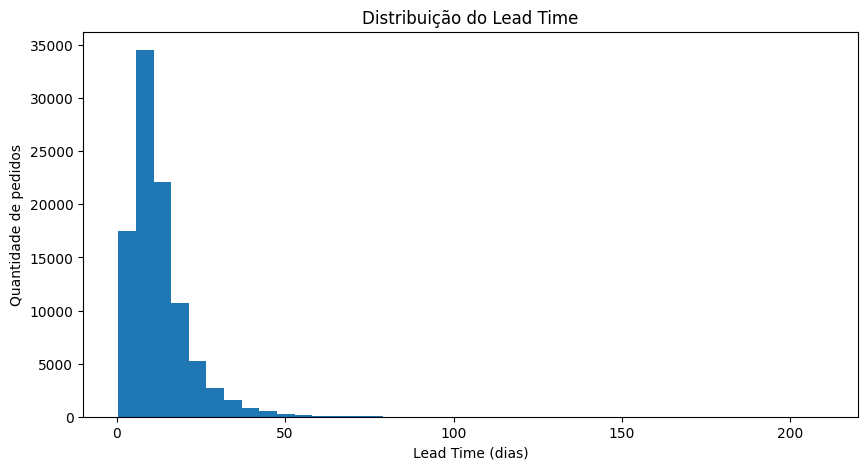

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(lead_time, bins=40)
plt.title('Distribuição do Lead Time')
plt.xlabel('Lead Time (dias)')
plt.ylabel('Quantidade de pedidos')
plt.show()

## 3. SLA — cumprimento do prazo de entrega

O SLA será analisado considerando se o pedido foi entregue dentro ou depois da data estimada.

O objetivo é medir o percentual de pedidos atendidos no prazo e dimensionar o volume de atrasos.

In [7]:
pedidos_entregues['order_estimated_delivery_date'] = pd.to_datetime(
    pedidos_entregues['order_estimated_delivery_date']
)

# Identificação dos pedidos atrasados
pedidos_entregues['atrasado'] = (
    pedidos_entregues['order_delivered_customer_date']
    > pedidos_entregues['order_estimated_delivery_date']
)

# Dias de atraso
pedidos_entregues['atraso_dias'] = (
    pedidos_entregues['order_delivered_customer_date']
    - pedidos_entregues['order_estimated_delivery_date']
).dt.days

total_pedidos = len(pedidos_entregues)
pedidos_atrasados = pedidos_entregues['atrasado'].sum()
pedidos_no_prazo = total_pedidos - pedidos_atrasados

sla = pedidos_no_prazo / total_pedidos * 100

print(f"Total de pedidos entregues: {total_pedidos:,}")
print(f"Pedidos no prazo: {pedidos_no_prazo:,}")
print(f"Pedidos atrasados: {pedidos_atrasados:,}")
print(f"SLA: {sla:.1f}%")

Total de pedidos entregues: 96,478
Pedidos no prazo: 88,652
Pedidos atrasados: 7,826
SLA: 91.9%


### 3.1 Atraso médio e mediano

Além do percentual de pedidos atrasados, observo a intensidade desses atrasos.

In [8]:
atrasos = pedidos_entregues.loc[
    pedidos_entregues['atrasado'] == True,
    'atraso_dias'
].dropna()

print(f"Atraso médio: {atrasos.mean():.2f} dias")
print(f"Mediana do atraso: {atrasos.median():.2f} dias")

Atraso médio: 8.87 dias
Mediana do atraso: 5.00 dias


### 3.2 Outliers do SLA

Aplico o mesmo método IQR somente aos pedidos atrasados. A análise identifica valores extremos de atraso sem alterar a métrica oficial de SLA.

In [9]:
Q1_atraso = atrasos.quantile(0.25)
Q3_atraso = atrasos.quantile(0.75)

IQR_atraso = Q3_atraso - Q1_atraso

limite_superior_atraso = Q3_atraso + 1.5 * IQR_atraso

outliers_atraso = atrasos[
    atrasos > limite_superior_atraso
]

print(
    "Quantidade de possíveis outliers:",
    len(outliers_atraso)
)

print(
    "Percentual entre os atrasados:",
    len(outliers_atraso) / len(atrasos) * 100
)

print(
    "Média com outliers:",
    atrasos.mean()
)

print(
    "Média sem outliers:",
    atrasos[
        atrasos <= limite_superior_atraso
    ].mean()
)

Quantidade de possíveis outliers: 486
Percentual entre os atrasados: 6.210069000766675
Média com outliers: 8.866854076156402
Média sem outliers: 6.296457765667575


**Resultado:** foram identificados **486 possíveis outliers**, equivalentes a **6,21% dos pedidos atrasados**. A média dos atrasos é de **8,87 dias** e cai para **6,30 dias** quando os valores extremos são retirados.

## 4. SLA por estado

Para identificar diferenças regionais, comparo o percentual de pedidos atrasados entre os estados. Para evitar conclusões baseadas em amostras muito pequenas, considero estados com pelo menos 1.000 pedidos.

In [10]:
# Adicionar o estado do cliente aos pedidos entregues
pedidos_entregues = pedidos_entregues.merge(
    dim_clientes[['customer_id', 'customer_state']],
    on='customer_id',
    how='left'
)

In [11]:
# Verificar se o customer_state foi adicionado corretamente aos pedidos
pedidos_entregues[['customer_id', 'customer_state']].head()

# Calcular o SLA por estado do cliente
# Agrupar os pedidos entregues por estado e calcular o total e os pedidos atrasados
sla_estado = (
    pedidos_entregues
    .groupby('customer_state')
    .agg(
        total_pedidos=('order_id', 'count'),
        pedidos_atrasados=('atrasado', 'sum')
    )
    .reset_index()
)

# Calcular o percentual de pedidos atrasados por estado
sla_estado['percentual_atraso'] = (
    sla_estado['pedidos_atrasados'] /
    sla_estado['total_pedidos'] * 100
)

# Filtro explícito: só estados com pelo menos 1.000 pedidos entram na comparação
sla_estado_filtrado = sla_estado[sla_estado['total_pedidos'] >= 1000].copy()

# Ordenar os estados do maior para o menor percentual de atraso
sla_estado_filtrado.sort_values('percentual_atraso', ascending=False)

,customer_state,total_pedidos,pedidos_atrasados,percentual_atraso
5,CE,1279,196,15.324472
4,BA,3256,457,14.035627
18,RJ,12350,1664,13.473684
7,ES,1995,244,12.230576
15,PE,1593,172,10.797238
23,SC,3546,346,9.757473
8,GO,1957,160,8.175779
22,RS,5345,382,7.146866
6,DF,2080,147,7.067308
25,SP,40501,2387,5.893682


In [12]:
# Criar o mapeamento dos estados brasileiros para suas respectivas regiões

regioes = {
    'AC': 'Norte',
    'AP': 'Norte',
    'AM': 'Norte',
    'PA': 'Norte',
    'RO': 'Norte',
    'RR': 'Norte',
    'TO': 'Norte',

    'AL': 'Nordeste',
    'BA': 'Nordeste',
    'CE': 'Nordeste',
    'MA': 'Nordeste',
    'PB': 'Nordeste',
    'PE': 'Nordeste',
    'PI': 'Nordeste',
    'RN': 'Nordeste',
    'SE': 'Nordeste',

    'DF': 'Centro-Oeste',
    'GO': 'Centro-Oeste',
    'MT': 'Centro-Oeste',
    'MS': 'Centro-Oeste',

    'ES': 'Sudeste',
    'MG': 'Sudeste',
    'RJ': 'Sudeste',
    'SP': 'Sudeste',

    'PR': 'Sul',
    'RS': 'Sul',
    'SC': 'Sul'
}

# Adicionar a região correspondente a cada estado (base completa, para o mapa de calor)
sla_estado['regiao'] = sla_estado['customer_state'].map(regioes)
sla_estado_filtrado['regiao'] = sla_estado_filtrado['customer_state'].map(regioes)
sla_estado_filtrado.head()

,customer_state,total_pedidos,pedidos_atrasados,percentual_atraso,regiao
4,BA,3256,457,14.035627,Nordeste
5,CE,1279,196,15.324472,Nordeste
6,DF,2080,147,7.067308,Centro-Oeste
7,ES,1995,244,12.230576,Sudeste
8,GO,1957,160,8.175779,Centro-Oeste


In [13]:
# Criar uma tabela com o percentual de atraso por região e estado
# (mapa de calor usa a base completa, sem o filtro de 1.000 pedidos, só para visualização)

heatmap_atrasos = sla_estado.pivot(
    index='regiao',
    columns='customer_state',
    values='percentual_atraso'
)

heatmap_atrasos

customer_state,AC,AL,AM,AP,BA,CE,DF,ES,GO,MA,...,PR,RJ,RN,RO,RR,RS,SC,SE,SP,TO
regiao,,,,,,,,,,,,,,,,,,,,,
Centro-Oeste,NaN,NaN,NaN,NaN,NaN,NaN,7.067308,NaN,8.175779,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Nordeste,NaN,23.929471,NaN,NaN,14.035627,15.324472,NaN,NaN,NaN,19.665272,...,NaN,NaN,10.759494,NaN,NaN,NaN,NaN,15.223881,NaN,NaN
Norte,3.75,NaN,4.137931,4.477612,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,2.880658,12.195122,NaN,NaN,NaN,NaN,12.773723
Sudeste,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.230576,NaN,NaN,...,NaN,13.473684,NaN,NaN,NaN,NaN,NaN,NaN,5.893682,NaN
Sul,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.996953,NaN,NaN,NaN,NaN,7.146866,9.757473,NaN,NaN,NaN


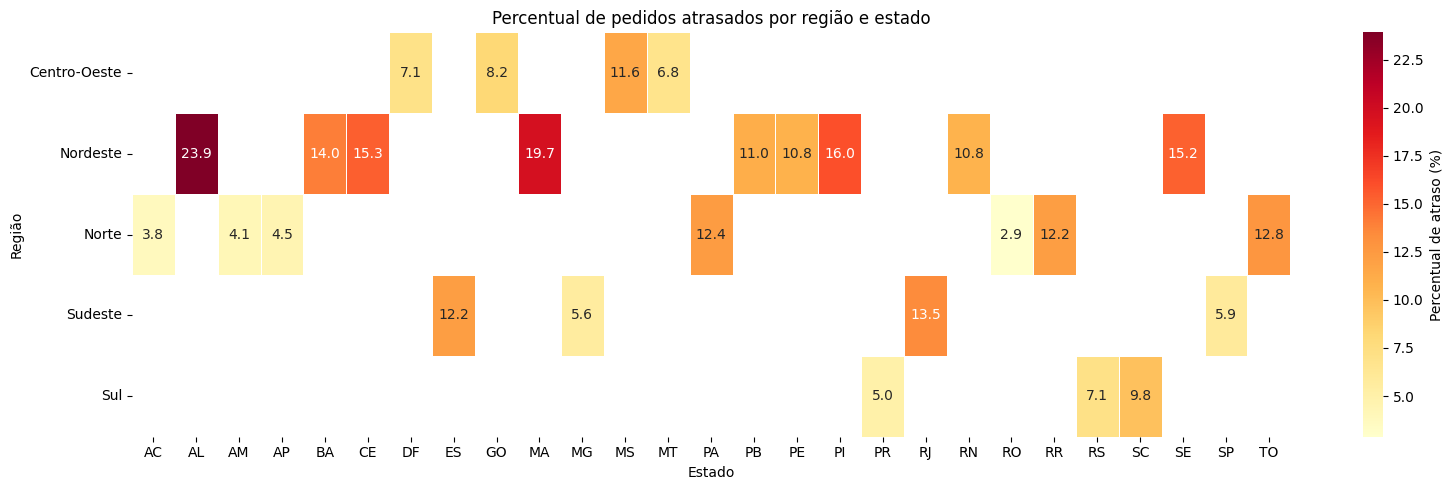

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Criar o mapa de calor do percentual de pedidos atrasados
# por região e estado.

plt.figure(figsize=(16, 5))

sns.heatmap(
    heatmap_atrasos,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Percentual de atraso (%)'}
)

plt.title('Percentual de pedidos atrasados por região e estado')
plt.xlabel('Estado')
plt.ylabel('Região')
plt.tight_layout()

plt.show()

### Principais resultados por estado

Entre os estados com pelo menos 1.000 pedidos, os maiores percentuais de atraso observados foram:

- **CE: 15,32%**
- **BA: 14,04%**
- **RJ: 13,47%**
- **ES: 12,23%**
- **PE: 10,80%**

Os menores percentuais foram:

- **PR: 5,00%**
- **MG: 5,61%**
- **SP: 5,89%**

Essas diferenças indicam que o desempenho logístico não é homogêneo entre as regiões e pode estar relacionado a características específicas das operações e das rotas de entrega.

## 5. Atraso × satisfação do cliente

Nesta etapa, cruzo o cumprimento do prazo com a avaliação para verificar se o atraso está associado a uma redução da satisfação do cliente.

In [15]:
reviews_pedido = order_reviews[
    ['order_id', 'review_score']
].drop_duplicates('order_id')

pedidos_review = pedidos_entregues.merge(
    reviews_pedido,
    on='order_id',
    how='left'
)

review_sla = (
    pedidos_review
    .dropna(subset=['review_score'])
    .groupby('atrasado')['review_score']
    .mean()
)

print(review_sla.round(2))

nota_no_prazo = review_sla[False]
nota_atrasado = review_sla[True]
queda_percentual = (1 - nota_atrasado / nota_no_prazo) * 100

print(f"\nQueda percentual na nota (atrasado vs. no prazo): {queda_percentual:.2f}%")

atrasado
False    4.29
True     2.57
Name: review_score, dtype: float64

Queda percentual na nota (atrasado vs. no prazo): 40.26%


O resultado indica uma associação forte entre atraso e pior avaliação da experiência de compra. Isso é uma associação observacional — outros fatores (categoria, região, valor do pedido) também podem influenciar os dois lados.

## 6. Impacto financeiro dos atrasos

Para dimensionar o impacto econômico, considero a receita associada aos pedidos atrasados e, em seguida, identifico a parcela classificada como receita em risco a partir dos pedidos atrasados que receberam avaliações baixas. Dessa forma, a análise considera a receita total dos pedidos, incluindo aqueles compostos por mais de um item.

In [16]:
# Receita por pedido
# Usamos fato_pedidos (nível de item) para não perder itens de pedidos
# com mais de uma unidade, que "pedidos_entregues" já deduplicou por pedido.

pedidos_atrasados_ids = pedidos_entregues.loc[
    pedidos_entregues['atrasado'] == True,
    'order_id'
]

receita_atrasados = fato_pedidos[
    fato_pedidos['order_id'].isin(pedidos_atrasados_ids)
]['price'].sum()

print(
    f"Receita em pedidos atrasados: R$ {receita_atrasados:,.2f}"
)

Receita em pedidos atrasados: R$ 1,158,920.51


## Receita em risco

In [17]:
receita_em_risco = receita_atrasados * (queda_percentual / 100)

print(f"Queda percentual na nota: {queda_percentual:.2f}%")
print(f"Receita em risco: R$ {receita_em_risco:,.2f}")

Queda percentual na nota: 40.26%
Receita em risco: R$ 466,604.06


## Conclusão

Com essa análise, é possível concluir que o desempenho logístico é relevante não só para o prazo de entrega, mas também para a experiência do cliente e para o resultado financeiro.

Apesar da maioria dos pedidos estar dentro do SLA, ainda existe um volume relevante de pedidos atrasados. Além disso, os estados apresentam desempenhos diferentes e os pedidos atrasados têm uma avaliação média muito inferior à dos pedidos no prazo.

Quando essa diferença é levada para o aspecto financeiro, ela representa uma parcela relevante de receita em risco.

Por isso, a principal conclusão é que a logística precisa ser acompanhada de forma preventiva.

## Recomendações

**1. Monitorar o SLA de forma preventiva**
Criar alertas para pedidos próximos de ultrapassar a data estimada.

**2. Priorizar as regiões mais críticas**
Investigar causas dos atrasos nas regiões mais críticas.

**3. Integrar indicadores logísticos e de satisfação**
Acompanhar SLA, atraso e Review Score conjuntamente.

**4. Priorizar ações pelo impacto financeiro e operacional**
Direcionar recursos para gargalos que combinem alto volume de atrasos, baixa satisfação e maior impacto financeiro.

**5. Trabalhar na redução do Lead Time**
Decompor o processo em compra, aprovação, preparação/postagem, transporte e entrega.